In [1]:
import pandas as pd
import numpy as np

# Load ML-enriched session data
df = pd.read_csv(
    "../Data/processed/acn_caltech_2019_anomalies.csv"
)

# Restore timestamp columns
timestamp_cols = [
    "connectionTime_local",
    "disconnectTime_local",
    "doneChargingTime_local"
]

for col in timestamp_cols:
    df[col] = pd.to_datetime(df[col], utc=True).dt.tz_convert(
        "America/Los_Angeles"
    )

print("Sessions:", len(df))
print("Unique chargers:", df["stationID"].nunique())

print("\nTime range:")
print("Start:", df["connectionTime_local"].min())
print("End:", df["disconnectTime_local"].max())

Sessions: 9817
Unique chargers: 54

Time range:
Start: 2019-01-01 10:09:17-08:00
End: 2019-12-31 13:19:33-08:00


In [2]:
def get_charger_states(replay_time, data):
    replay_time = pd.Timestamp(replay_time)

    # Match replay timestamp to dataset timezone
    if replay_time.tzinfo is None:
        replay_time = replay_time.tz_localize("America/Los_Angeles")

    charger_ids = sorted(data["stationID"].unique())
    states = []

    for charger in charger_ids:

        charger_sessions = data[data["stationID"] == charger]

        # Session occupying this charger at replay_time
        active = charger_sessions[
            (charger_sessions["connectionTime_local"] <= replay_time) &
            (charger_sessions["disconnectTime_local"] > replay_time)
        ]

        if active.empty:
            states.append({
                "stationID": charger,
                "state": "Available",
                "anomaly_warning": False,
                "kWhDelivered": 0
            })
            continue

        session = active.iloc[0]

        done_time = session["doneChargingTime_local"]

        # Determine operational state
        if pd.isna(done_time) or replay_time < done_time:
            state = "Charging"
        else:
            state = "Connected / Idle"

        states.append({
            "stationID": charger,
            "state": state,
            "anomaly_warning": session["status"] == "Anomaly",
            "kWhDelivered": round(session["kWhDelivered"], 2)
        })

    return pd.DataFrame(states)

In [3]:
replay_time = "2019-01-08 10:30:00"

snapshot = get_charger_states(replay_time, df)

print("Digital Twin Snapshot:", replay_time)

print("\nState counts:")
print(snapshot["state"].value_counts())

print("\nAnomaly warnings:", snapshot["anomaly_warning"].sum())

snapshot.head(15)

Digital Twin Snapshot: 2019-01-08 10:30:00

State counts:
state
Available           30
Charging            21
Connected / Idle     3
Name: count, dtype: int64

Anomaly warnings: 2


,stationID,state,anomaly_warning,kWhDelivered
0,2-39-123-23,Connected / Idle,False,4.04
1,2-39-123-557,Available,False,0.00
2,2-39-124-22,Available,False,0.00
3,2-39-124-558,Available,False,0.00
4,2-39-125-21,Available,False,0.00
5,2-39-125-559,Available,False,0.00
6,2-39-126-20,Available,False,0.00
7,2-39-126-560,Available,False,0.00
8,2-39-127-19,Charging,False,26.70
9,2-39-127-561,Available,False,0.00


In [4]:
warning_chargers = snapshot[
    snapshot["anomaly_warning"] == True
]

print("Chargers with anomaly warnings:")
print(warning_chargers.to_string(index=False))

Chargers with anomaly warnings:
  stationID    state  anomaly_warning  kWhDelivered
2-39-79-377 Charging             True          5.36
2-39-79-379 Charging             True         15.76


In [5]:
warning_ids = warning_chargers["stationID"].tolist()

warning_sessions = df[
    (df["stationID"].isin(warning_ids)) &
    (df["connectionTime_local"] <= pd.Timestamp(
        replay_time,
        tz="America/Los_Angeles"
    )) &
    (df["disconnectTime_local"] > pd.Timestamp(
        replay_time,
        tz="America/Los_Angeles"
    ))
]

warning_sessions[
    [
        "stationID",
        "connectionTime_local",
        "doneChargingTime_local",
        "disconnectTime_local",
        "kWhDelivered",
        "connected_hours",
        "charging_hours",
        "idle_hours",
        "anomaly_score"
    ]
].round(2)

C:\Users\Deandra Fernandes\AppData\Local\Temp\ipykernel_32436\588177381.py:27: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ].round(2)


,stationID,connectionTime_local,doneChargingTime_local,disconnectTime_local,kWhDelivered,connected_hours,charging_hours,idle_hours,anomaly_score
168,2-39-79-379,2019-01-08 07:18:16-08:00,2019-01-08 21:50:24-08:00,2019-01-08 21:50:28-08:00,15.76,14.54,14.54,0.0,0.09
169,2-39-79-377,2019-01-08 07:56:19-08:00,2019-01-08 18:19:31-08:00,2019-01-08 18:19:35-08:00,5.36,10.39,10.39,0.0,0.01


In [6]:
replay_ts = pd.Timestamp(
    replay_time,
    tz="America/Los_Angeles"
)

warning_sessions = df[
    (df["anomaly_warning"] == True)
] if "anomaly_warning" in df.columns else df[
    (df["status"] == "Anomaly") &
    (df["connectionTime_local"] <= replay_ts) &
    (df["disconnectTime_local"] > replay_ts)
]

display_cols = [
    "stationID",
    "connectionTime_local",
    "doneChargingTime_local",
    "disconnectTime_local",
    "kWhDelivered",
    "connected_hours",
    "charging_hours",
    "idle_hours",
    "anomaly_score"
]

warning_sessions[display_cols]

,stationID,connectionTime_local,doneChargingTime_local,disconnectTime_local,kWhDelivered,connected_hours,charging_hours,idle_hours,anomaly_score
168,2-39-79-379,2019-01-08 07:18:16-08:00,2019-01-08 21:50:24-08:00,2019-01-08 21:50:28-08:00,15.760,14.536667,14.535556,0.001111,0.085522
169,2-39-79-377,2019-01-08 07:56:19-08:00,2019-01-08 18:19:31-08:00,2019-01-08 18:19:35-08:00,5.359,10.387778,10.386667,0.001111,0.010058


In [7]:
replay_ts = pd.Timestamp(
    replay_time,
    tz="America/Los_Angeles"
)

warning_sessions = df[
    (df["status"] == "Anomaly") &
    (df["connectionTime_local"] <= replay_ts) &
    (df["disconnectTime_local"] > replay_ts)
]

warning_sessions[
    [
        "stationID",
        "connectionTime_local",
        "doneChargingTime_local",
        "disconnectTime_local",
        "kWhDelivered",
        "connected_hours",
        "charging_hours",
        "idle_hours",
        "anomaly_score"
    ]
]

,stationID,connectionTime_local,doneChargingTime_local,disconnectTime_local,kWhDelivered,connected_hours,charging_hours,idle_hours,anomaly_score
168,2-39-79-379,2019-01-08 07:18:16-08:00,2019-01-08 21:50:24-08:00,2019-01-08 21:50:28-08:00,15.760,14.536667,14.535556,0.001111,0.085522
169,2-39-79-377,2019-01-08 07:56:19-08:00,2019-01-08 18:19:31-08:00,2019-01-08 18:19:35-08:00,5.359,10.387778,10.386667,0.001111,0.010058


In [8]:
total_chargers = len(snapshot)

available = (snapshot["state"] == "Available").sum()
charging = (snapshot["state"] == "Charging").sum()
idle = (snapshot["state"] == "Connected / Idle").sum()
occupied = charging + idle
warnings = snapshot["anomaly_warning"].sum()

utilization = (occupied / total_chargers) * 100
charging_rate = (charging / total_chargers) * 100

digital_twin_kpis = {
    "Replay Time": replay_time,
    "Total Chargers": total_chargers,
    "Available": available,
    "Charging": charging,
    "Connected / Idle": idle,
    "Occupied": occupied,
    "Utilization (%)": round(utilization, 2),
    "Actively Charging (%)": round(charging_rate, 2),
    "Anomaly Warnings": int(warnings)
}

print("DIGITAL TWIN STATION SUMMARY")
print("-" * 35)

for key, value in digital_twin_kpis.items():
    print(f"{key}: {value}")

DIGITAL TWIN STATION SUMMARY
-----------------------------------
Replay Time: 2019-01-08 10:30:00
Total Chargers: 54
Available: 30
Charging: 21
Connected / Idle: 3
Occupied: 24
Utilization (%): 44.44
Actively Charging (%): 38.89
Anomaly Warnings: 2


In [9]:
test_times = [
    "2019-01-08 06:00:00",
    "2019-01-08 10:30:00",
    "2019-01-08 14:00:00",
    "2019-01-08 18:00:00",
    "2019-01-08 22:00:00"
]

replay_results = []

for time in test_times:
    
    temp_snapshot = get_charger_states(time, df)

    available = (temp_snapshot["state"] == "Available").sum()
    charging = (temp_snapshot["state"] == "Charging").sum()
    idle = (temp_snapshot["state"] == "Connected / Idle").sum()
    occupied = charging + idle
    warnings = temp_snapshot["anomaly_warning"].sum()

    replay_results.append({
        "time": time,
        "available": available,
        "charging": charging,
        "connected_idle": idle,
        "occupied": occupied,
        "utilization_percent": round(
            occupied / len(temp_snapshot) * 100, 2
        ),
        "anomaly_warnings": int(warnings)
    })

replay_summary = pd.DataFrame(replay_results)

replay_summary

,time,available,charging,connected_idle,occupied,utilization_percent,anomaly_warnings
0,2019-01-08 06:00:00,52,1,1,2,3.70,0
1,2019-01-08 10:30:00,30,21,3,24,44.44,2
2,2019-01-08 14:00:00,23,14,17,31,57.41,2
3,2019-01-08 18:00:00,35,5,14,19,35.19,2
4,2019-01-08 22:00:00,50,2,2,4,7.41,0


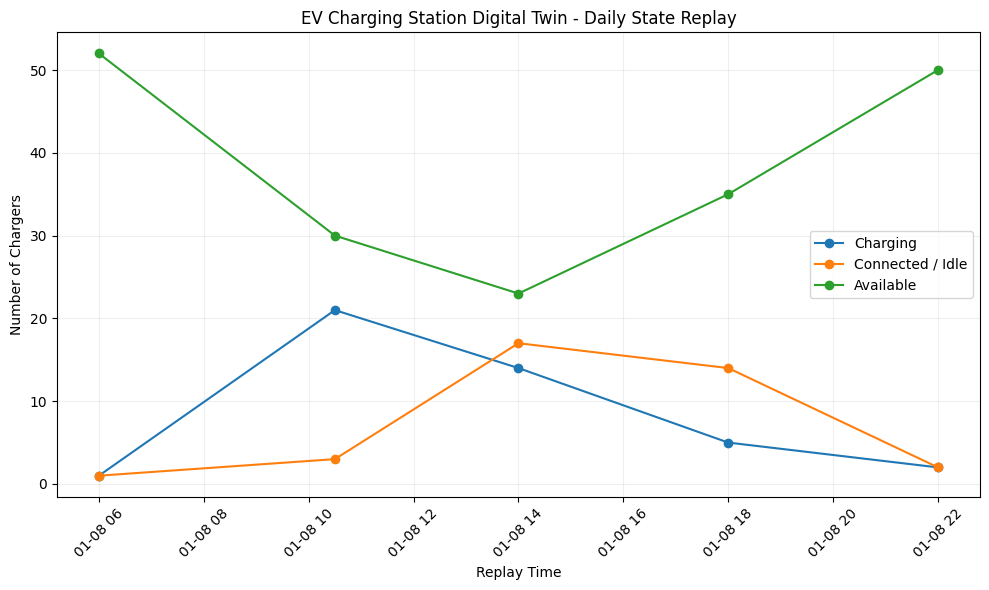

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

times = pd.to_datetime(replay_summary["time"])

plt.plot(
    times,
    replay_summary["charging"],
    marker="o",
    label="Charging"
)

plt.plot(
    times,
    replay_summary["connected_idle"],
    marker="o",
    label="Connected / Idle"
)

plt.plot(
    times,
    replay_summary["available"],
    marker="o",
    label="Available"
)

plt.xlabel("Replay Time")
plt.ylabel("Number of Chargers")
plt.title("EV Charging Station Digital Twin - Daily State Replay")

plt.legend()
plt.grid(alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [12]:
import os

print(os.getcwd())

C:\Users\Deandra Fernandes\OneDrive\Desktop\EV_Charging_Digital_Twin\notebooks
